# Punto 6 (1.4) — El Reto

Encuentra una combinación de hasta 4 transformaciones sucesivas y sin repetir (escala de grises, negativo, gamma, logarítmica, lineal a trozos) aplicadas a `images/Input.tif` que logren un SSIM ≥ ~95% respecto a `images/Output.tif`. La imagen de salida solo se usa para comparar el resultado final, no para el proceso.

Recomendaciones: revisa las dimensiones de las imágenes e identifica efectos similares a los generados por las transformaciones vistas en el curso.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
import cv2


## Carga de imágenes



In [2]:
input_img = np.array(Image.open("../images/Input.tif").convert("RGB"))
output_ref = np.array(Image.open("../images/Output.tif").convert("L"))
print(input_img.shape, output_ref.shape)


(832, 1248, 3) (832, 1248)


## Exploración / pruebas de transformaciones

Se prueba cada transformación de forma incremental, evaluando el SSIM en cada paso para decidir si conviene mantenerla o probar otra.

SSIM solo gris: -0.0953


SSIM gris + negativo: 0.9456


SSIM gris + negativo + lineal a trozos: 0.8379
SSIM gris + negativo + lineal a trozos + gamma: 0.9765


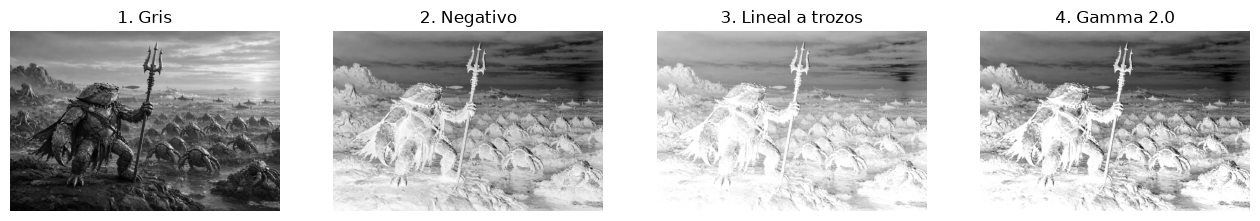

In [3]:
gray0 = np.array(Image.fromarray(input_img).convert("L"))
print(f"SSIM solo gris: {ssim(gray0, output_ref):.4f}")

intento_1 = cv2.bitwise_not(gray0)
print(f"SSIM gris + negativo: {ssim(intento_1, output_ref):.4f}")

intento_2 = np.zeros_like(intento_1)
cv2.intensity_transform.contrastStretching(intento_1, intento_2, 30, 100, 220, 255)
print(f"SSIM gris + negativo + lineal a trozos: {ssim(intento_2, output_ref):.4f}")

intento_3 = np.zeros_like(intento_2)
cv2.intensity_transform.gammaCorrection(intento_2, intento_3, 2.0)
print(f"SSIM gris + negativo + lineal a trozos + gamma: {ssim(intento_3, output_ref):.4f}")

resultado = intento_3

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, title in zip(
    axs,
    [gray0, intento_1, intento_2, resultado],
    ["1. Gris", "2. Negativo", "3. Lineal a trozos", "4. Gamma 2.0"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


## Evaluación con SSIM



In [4]:
score = ssim(resultado, output_ref)
print(f"SSIM final: {score:.4f}")


SSIM final: 0.9765


## Mejor aproximación

SSIM obtenido: **0.9765** (~97.65%)

Cadena de transformaciones aplicada sobre Input.tif: escala de grises -> negativo -> lineal a trozos (r1=30, s1=100, r2=220, s2=255) -> gamma (gamma=2.0), usando cv2.bitwise_not y cv2.intensity_transform (contrastStretching, gammaCorrection).

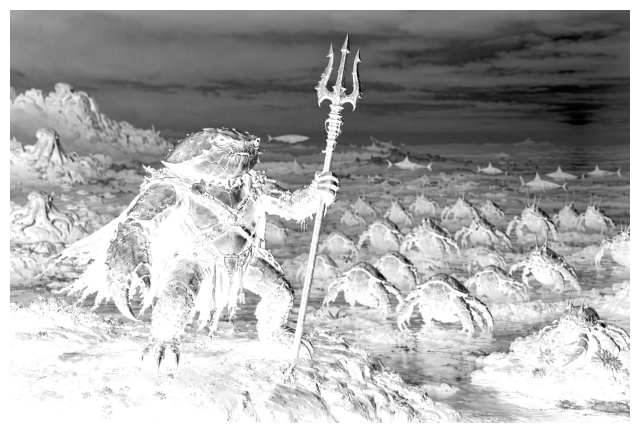

In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(resultado, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.savefig("../results/punto6_mejor_aproximacion.png", bbox_inches="tight", pad_inches=0)
